<a href="https://colab.research.google.com/github/zurii-07/MindScope-AI-Powered-Mental-Wellness-Assistant/blob/Model-Training/Reddit_Mental_Health_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

01. Performing Exploratory Data Analysis

01. Dataset Shape: (5957, 4)

Data Types:
 text            object
title           object
target           int64
target_label    object
dtype: object

Missing Values:
 text            350
title             0
target            0
target_label      0
dtype: int64

Class Distribution:
 target_label
Depression              1202
Personality disorder    1201
Anxiety                 1188
Bipolar disorder        1185
Stress                  1181
Name: count, dtype: int64


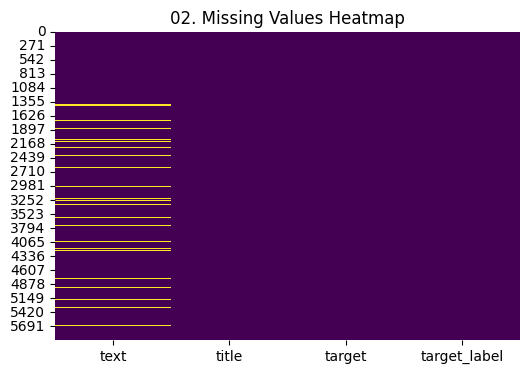

/tmp/ipython-input-2868379118.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='target_label', order=df['target_label'].value_counts().index, palette='Set2')


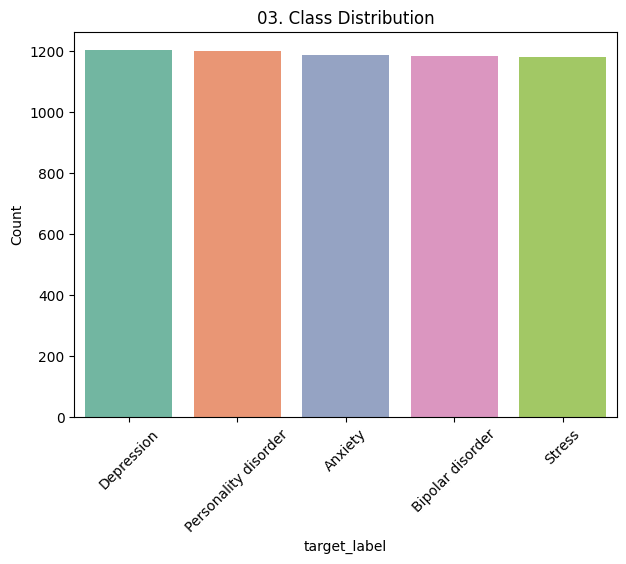

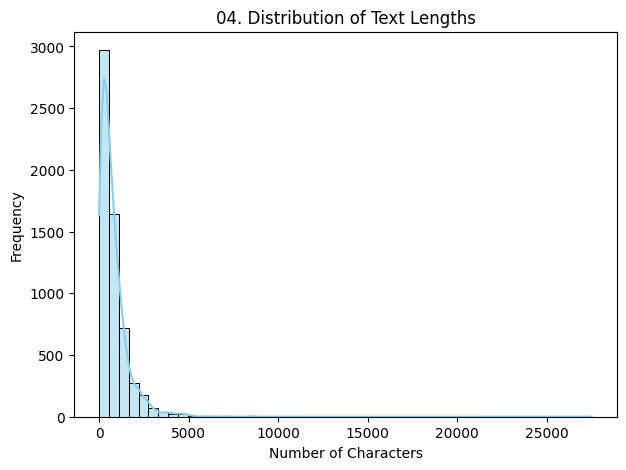

05. Potential outliers in text length: 349 rows


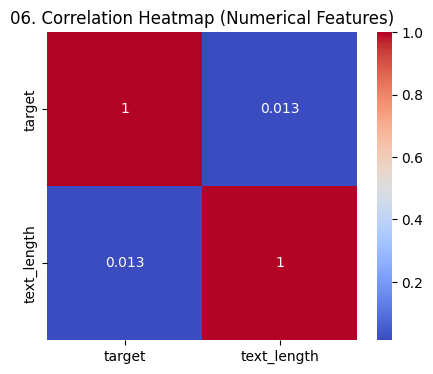

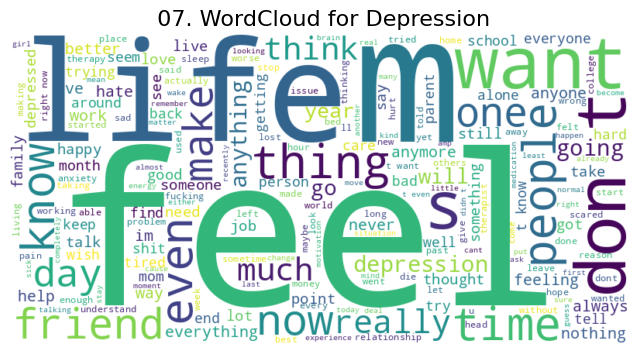

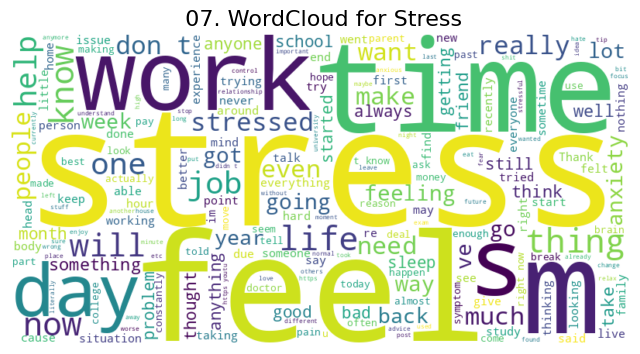

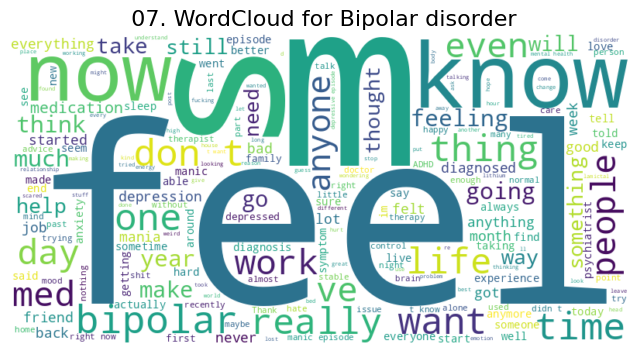

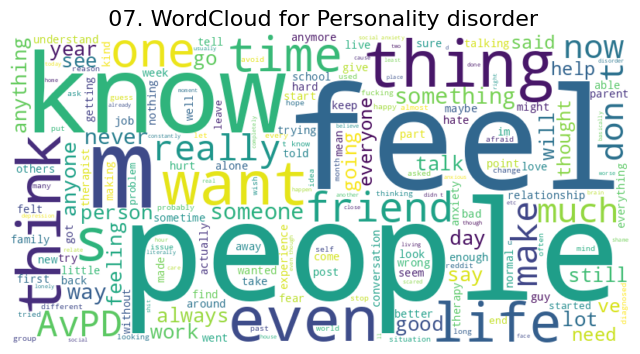

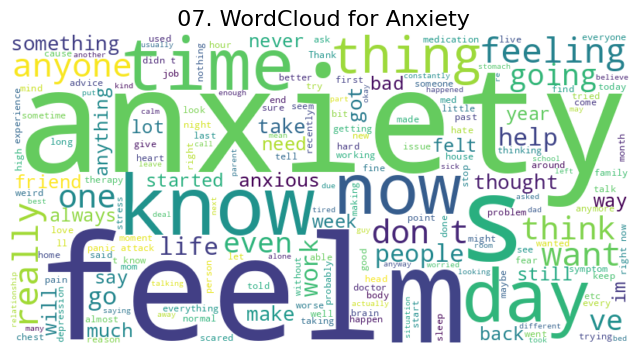


 08. Summary statistics for numerical features:
             target   text_length
count  5957.000000   5957.000000
mean      2.002182    787.263220
std       1.412252    879.580159
min       0.000000      1.000000
25%       1.000000    256.000000
50%       2.000000    553.000000
75%       3.000000   1035.000000
max       4.000000  27542.000000


In [7]:
#Import libraries
import pandas as pd #for loading and manipulating tabular patient data
import numpy as np #for numerical operations - here for outlier detection using IQR
import matplotlib.pyplot as plt #for visualizations
import seaborn as sns
from wordcloud import WordCloud #generating word clouds for each target label

#Load the dataset
df = pd.read_csv('/content/drive/MyDrive/MindScope/datasets_to_be_cleaned/data_to_be_cleansed1.csv/data_to_be_cleansed.csv')

#Drop unnecessary index column if present
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True) #drops the redundant index column

#Map target values to labels
target_mapping = {
    0: 'Stress',
    1: 'Depression',
    2: 'Bipolar disorder',
    3: 'Personality disorder',
    4: 'Anxiety'
}
df['target_label'] = df['target'].map(target_mapping)

#1. Dataset overview
print("01. Dataset Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nClass Distribution:\n", df['target_label'].value_counts())

#2. Missing value visualization
plt.figure(figsize=(6,4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("02. Missing Values Heatmap")
plt.show()


#3. Class distribution
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='target_label', order=df['target_label'].value_counts().index, palette='Set2')
plt.title("03. Class Distribution")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


#4. Text length analysis
df['text_length'] = df['text'].astype(str).apply(len)
plt.figure(figsize=(7,5))
sns.histplot(df['text_length'], bins=50, kde=True, color='skyblue')
plt.title("04. Distribution of Text Lengths")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")
plt.show()


#5. Outlier detection in text length using IQR
q1, q3 = np.percentile(df['text_length'], [25, 75])
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers = df[(df['text_length'] < lower_bound) | (df['text_length'] > upper_bound)]
print(f"05. Potential outliers in text length: {len(outliers)} rows")


#6. Correlation heatmap for numerical features
num_cols = df.select_dtypes(include=np.number)
plt.figure(figsize=(5,4))
sns.heatmap(num_cols.corr(), annot=True, cmap='coolwarm')
plt.title("06. Correlation Heatmap (Numerical Features)")
plt.show()


#7. WordCloud for each class
for label in df['target_label'].unique():
    text_combined = " ".join(df[df['target_label'] == label]['text'].dropna().astype(str))
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_combined)
    plt.figure(figsize=(8,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f" 07. WordCloud for {label}", fontsize=16)
    plt.show()

#8. Summary statistics
print("\n 08. Summary statistics for numerical features:\n", df.describe())